# Standalone RevPAR LP Optimization (Convex Combination)

This notebook provides a completely self-contained implementation of the Hotel RevPAR optimization problem using Linear Programming (LP) and Gurobi.

### Mathematical Formulation
We use the **Convex-Combination** approach:
- **Variables**: $\lambda_{d,k} \ge 0$ (weight for each price breakpoint $k$ on day $d$).
- **Objective**: $\text{Maximize} \sum_{d} \sum_{k} \lambda_{d,k} R_{d,k}$.
- **Constraints**:
    - $\sum_{k} \lambda_{d,k} = 1$ (Weights must sum to 1 for each day).
    - $\sum_{d} \sum_{k} \lambda_{d,k} D_{d,k} \le C$ (Total sales must not exceed capacity).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gurobipy as gp
from gurobipy import GRB

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Sets and Parameters

We define the fundamental building blocks of the model: the time horizon, the price grid, and the hotel capacity.

In [2]:
# Configuration
HORIZON = 7        # Days to optimize
CAPACITY = 100     # Total rooms to sell
MIN_PRICE = 100.0
MAX_PRICE = 500.0
N_BREAKPOINTS = 11

# Set of Indices
D = range(HORIZON)
K = range(N_BREAKPOINTS)

# Price Grid (p_k)
price_grid = np.linspace(MIN_PRICE, MAX_PRICE, N_BREAKPOINTS)

print(f"Optimization Horizon: {HORIZON} days")
print(f"Capacity Constraint: {CAPACITY} rooms")
print(f"Price Grid: {price_grid}")

Optimization Horizon: 7 days
Capacity Constraint: 100 rooms
Price Grid: [100. 140. 180. 220. 260. 300. 340. 380. 420. 460. 500.]


## 2. Demand Matrix ($D_{d,k}$)

We define the predicted demand for each price point. Here, we use a log-linear demand model:
$D(p) = \text{base} \cdot e^{-\epsilon (\frac{p}{p_{avg}} - 1)}$

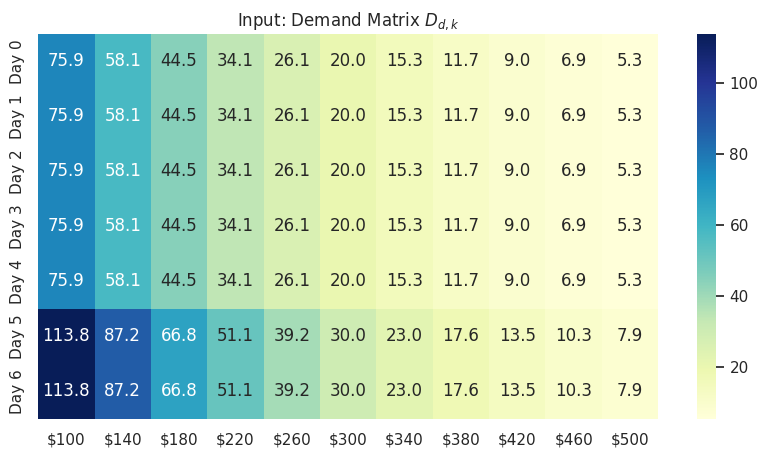

In [7]:
def custom_demand_model(horizon, price_grid, base_demand=20.0, elasticity=2.0):
    demand = np.zeros((horizon, len(price_grid)))
    avg_p = (price_grid[0] + price_grid[-1]) / 2.0
    for d in range(horizon):
        # Seasonality effect: Weekend (Day 5, 6) has higher demand
        seasonality = 1.5 if d >= 5 else 1.0
        for k, p in enumerate(price_grid):
            demand[d, k] = seasonality * base_demand * np.exp(-elasticity * (p/avg_p - 1.0))
    return demand

demand_matrix = custom_demand_model(HORIZON, price_grid)

df_demand = pd.DataFrame(demand_matrix, columns=[f"${p:.0f}" for p in price_grid], index=[f"Day {d}" for d in D])
plt.figure(figsize=(10, 5))
sns.heatmap(df_demand, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Input: Demand Matrix $D_{d,k}$")
plt.show()

## 3. Revenue Matrix ($R_{d,k}$)

Calculated as Price $\times$ Demand. This allows the model to see the trade-off between price and quantity.

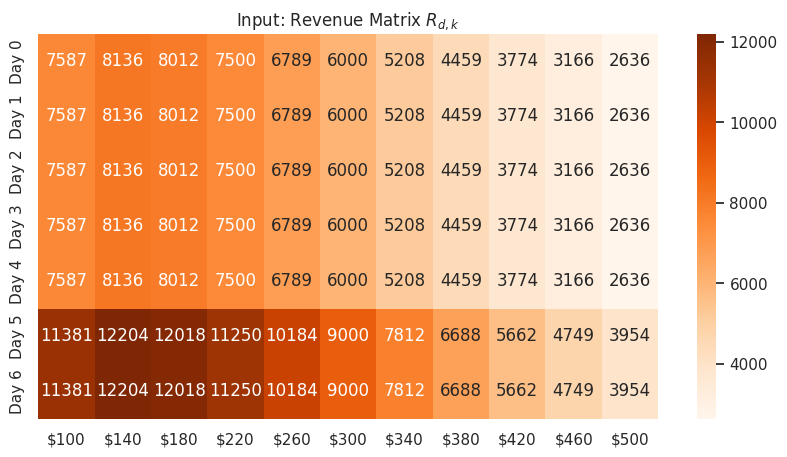

In [8]:
revenue_matrix = demand_matrix * price_grid[np.newaxis, :]

df_rev = pd.DataFrame(revenue_matrix, columns=[f"${p:.0f}" for p in price_grid], index=[f"Day {d}" for d in D])
plt.figure(figsize=(10, 5))
sns.heatmap(df_rev, annot=True, fmt=".0f", cmap="Oranges")
plt.title("Input: Revenue Matrix $R_{d,k}$")
plt.show()

## 4. Gurobi LP Model Formulation

In this cell, we build the mathematical model using `gurobipy`.

In [5]:
# 1. Initialize Model
m = gp.Model("RevPAR_LP")
m.setParam('OutputFlag', 1) # Show Gurobi log

# 2. Decision Variables: lambdas[day, price_index]
lambdas = m.addVars(D, K, lb=0.0, ub=1.0, name="lambda")

# 3. Objective Function: Maximize total revenue
obj = gp.quicksum(lambdas[d, k] * revenue_matrix[d, k] for d in D for k in K)
m.setObjective(obj, GRB.MAXIMIZE)

# 4. Constraints

# Constraint A: For each day, the weights must sum to 1 (Convex Combination)
for d in D:
    m.addConstr(gp.quicksum(lambdas[d, k] for k in K) == 1.0, name=f"sum_to_one_{d}")

# Constraint B: Total Rooms Sold must be <= Capacity
total_rooms = gp.quicksum(lambdas[d, k] * demand_matrix[d, k] for d in D for k in K)
m.addConstr(total_rooms <= CAPACITY, name="total_capacity")

print("Model built successfully. Ready to optimize.")

Restricted license - for non-production use only - expires 2027-11-29
Set parameter OutputFlag to value 1
Model built successfully. Ready to optimize.


## 5. Solve and Results

Executing the optimizer and extracting the optimal price/demand.

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: AMD Ryzen 9 9950X3D 16-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 16 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 8 rows, 77 columns and 154 nonzeros (Max)
Model fingerprint: 0x611fa9e2
Model has 77 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [3e+03, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+02]

Presolve time: 0.01s
Presolved: 8 rows, 77 columns, 154 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.5087182e+04   2.280678e+01   0.000000e+00      0s
      21    3.6951329e+04   0.000000e+00   0.000000e+00      0s

Solved in 21 iterations and 0.01 seconds (0.00 work units)
Optimal objective  3.695132886e+04

Optimal Revenue: $36,951.33
Total Capacity Used: 100.00 / 100


,Day,Price,Demand,Revenue
0,0,340.000000,15.318567,5208.312701
1,1,380.000000,11.732924,4458.511268
2,2,380.000000,11.732924,4458.511268
3,3,380.000000,11.732924,4458.511268
4,4,380.000000,11.732924,4458.511268
5,5,361.028318,20.150349,7221.204188
6,6,380.000000,17.599387,6687.766902


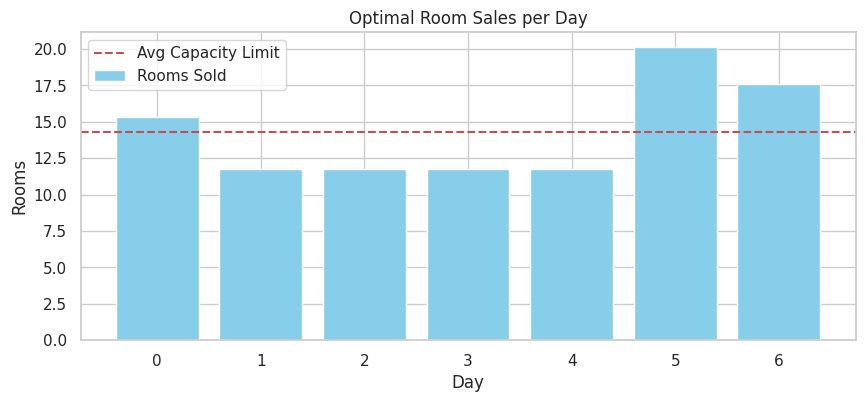

In [6]:
m.optimize()

if m.Status == GRB.OPTIMAL:
    print(f"\nOptimal Revenue: ${m.ObjVal:,.2f}")
    
    # Extract results
    opt_prices = []
    opt_demand = []
    opt_revenue = []
    
    for d in D:
        p_d = sum(lambdas[d, k].X * price_grid[k] for k in K)
        q_d = sum(lambdas[d, k].X * demand_matrix[d, k] for k in K)
        r_d = sum(lambdas[d, k].X * revenue_matrix[d, k] for k in K)
        
        opt_prices.append(p_d)
        opt_demand.append(q_d)
        opt_revenue.append(r_d)
    
    results_df = pd.DataFrame({
        "Day": D,
        "Price": opt_prices,
        "Demand": opt_demand,
        "Revenue": opt_revenue
    })
    
    print(f"Total Capacity Used: {sum(opt_demand):.2f} / {CAPACITY}")
    display(results_df)
    
    # Final Visualization
    plt.figure(figsize=(10, 4))
    plt.bar(D, opt_demand, color='skyblue', label='Rooms Sold')
    plt.axhline(y=CAPACITY/HORIZON, color='r', linestyle='--', label='Avg Capacity Limit')
    plt.title("Optimal Room Sales per Day")
    plt.xlabel("Day")
    plt.ylabel("Rooms")
    plt.legend()
    plt.show()
else:
    print("Optimal solution not found.")